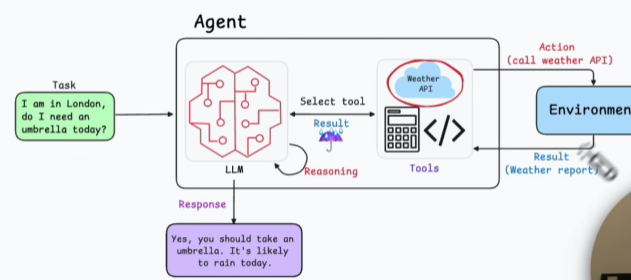

## MENTAL MODEL

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

from langchain_openai import ChatOpenAI

from langgraph.graph import START,END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# 1. Tools
@tool
def my_tool(a):
    ...

tools = [my_tool]


# 2. LLM
llm = ChatOpenAI(...)

llm_with_tools = llm.bind_tools(tools)


# 3. State
class State(TypedDict):
    messages: Annotated[list, add_messages]


# 4. LLM node
def chatbot(state):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }


# 5. Tool node
tool_node = ToolNode(tools)


# 6. Conditional routing
def should_continue(state):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END


# 7. Build graph
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.add_edge(START, "chatbot")

builder.add_conditional_edges(
    "chatbot",
    should_continue
)

# THIS CREATES THE REACT LOOP
builder.add_edge(
    "tools",
    "chatbot"
)


# 8. Compile
app = builder.compile()


# 9. Run
result = app.invoke({
    "messages": [
        HumanMessage(
            content="..."
        )
    ]
})

In [6]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

from langchain_openai import ChatOpenAI

from langgraph.graph import START,END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

#? Make Tools  

@tool
def add(a:int , b:int)->int:
    """Add two numbers"""
    return a+b

@tool
def multiply(a:int , b:int)->int:
    """Multiply two numbers"""
    return a*b 

tools=[add,multiply]

#? Create LLM

llm=ChatOpenAI(
    model="qwen/qwen3-4b-2507",
    base_url="http://127.0.0.1:1234/v1",
    api_key="dummy",
    temperature=0
)

#? Give llm access to tools 

llm_with_tools=llm.bind_tools(tools)

#? Create STATE

class State(TypedDict):
    messages:Annotated[list,add_messages]


#? Create LLM Node

def chatbot(state:State):
    response=llm_with_tools.invoke(
        state["messages"]
    )
    return{
        "messages":[response]
    }


#? Create Tool Node
tool_node=ToolNode(tools)

#? Create Conditional Edge

def should_continue(state:State):
    last_message=state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END

builder=StateGraph(State)

builder.add_node("chatbot",chatbot)
builder.add_node("tools",tool_node)

builder.add_edge(START,"chatbot")

builder.add_conditional_edges("chatbot",should_continue)

#? Create REACT Loop

builder.add_edge("tools","chatbot")

app=builder.compile()

result=app.invoke(
    {
        "messages":[
            HumanMessage(
                content="Add 5 and 9 , then multiply them by 2"
            )
        ]
    }
)

for message in result['messages']:
    print("=" * 60)

    print("TYPE:", type(message).__name__)

    print("CONTENT:", message.content)

    if hasattr(message, "tool_calls") and message.tool_calls:

        print("TOOL CALLS:")

        for tool_call in message.tool_calls:
            print(tool_call)

TYPE: HumanMessage
CONTENT: Add 5 and 9 , then multiply them by 2
TYPE: AIMessage
CONTENT: 

TOOL CALLS:
{'name': 'add', 'args': {'a': 5, 'b': 9}, 'id': '646353633', 'type': 'tool_call'}
{'name': 'multiply', 'args': {'a': 14, 'b': 2}, 'id': '357346069', 'type': 'tool_call'}
TYPE: ToolMessage
CONTENT: 14
TYPE: ToolMessage
CONTENT: 28
TYPE: AIMessage
CONTENT: The sum of 5 and 9 is 14. Multiplying 14 by 2 gives 28.
